## Radio Spectrum

**The file 0108+388_HI.dat is a spectrum towards the radio source COINS J0111+3906 (B0108+388) with the
Green Bank Telescope**

**The units are frequency [MHz] and flux density [Jy] and the absorption due to the 21-cm transition of neutral hydrogen (H i) is located between ν = 849 and 854 MHz**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('0108+388_HI.dat',delim_whitespace=True, header = None)
df.columns = ['MHz','Jy']

c = 299792458

**(a) Plot the spectrum over this range**

Text(0, 0.5, 'Flux density, $S$ [Jy]')

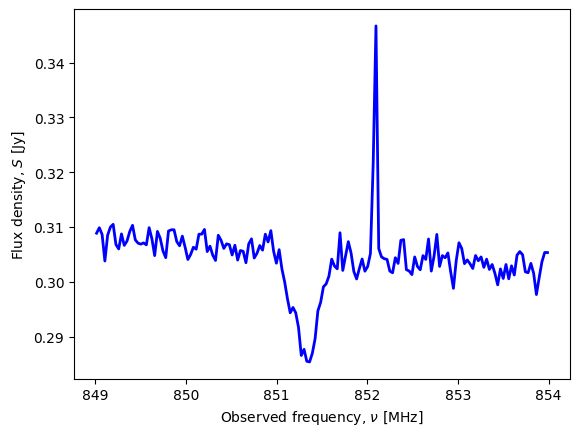

In [4]:
df = df[(df['MHz'] > 849) & (df['MHz'] < 854)].reset_index(); #df
plt.plot(df['MHz'],df['Jy'], lw = 2, c = 'b')
plt.xlabel(r'Observed frequency, $\nu$ [MHz]'); plt.ylabel('Flux density, $S$ [Jy]')

**(b) Frequency is not the most useful unit as it is redshift dependent. Velocity is not and offers more insight into the physics. The optical redshift of the galaxy where the absorption arises is z = 0.66847**
- (i) Convert the frequency into the velocity offset, ∆v in km/s
- (ii) Plot the spectrum with ∆v as the x-axis
- (iii) Comment on why you think the spectrum has ’flipped’

In [5]:
#(i) Convert the frequency into the velocity offset, ∆v in km/s
f_0 = 1420.40575/(0.66847+1)
df['v'] = 1e-3*c*(f_0 - df['MHz'])/f_0
df

,level_0,index,MHz,Jy,v
0,0,732,853.98699,0.305336,-938.361624
1,1,733,853.95648,0.305358,-927.617552
2,2,734,853.92596,0.303664,-916.869959
3,3,735,853.89544,0.300759,-906.122366
4,4,736,853.86493,0.297676,-895.378295
...,...,...,...,...,...
159,159,891,849.13500,0.308515,770.262684
160,160,892,849.10449,0.303800,781.006756
161,161,893,849.07397,0.308638,791.754349
162,162,894,849.04346,0.309870,802.498420


Text(0, 0.5, 'Flux density, $S$ [Jy]')

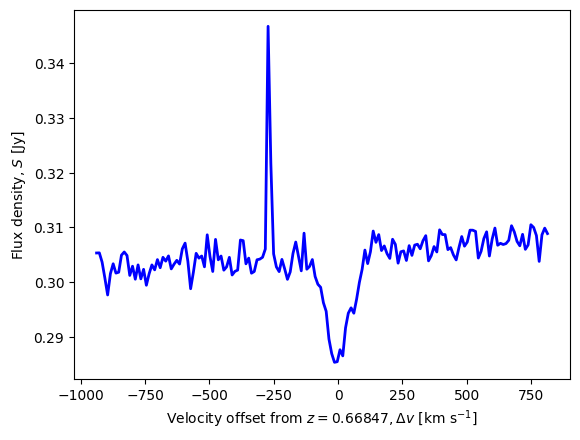

In [6]:
# (ii) Plot the spectrum with ∆v as the x-axis
plt.plot(df['v'],df['Jy'], lw = 2, c = 'b') 
plt.xlabel(r'Velocity offset from $z=0.66847, \Delta v$ [km s$^{-1}$]')
plt.ylabel('Flux density, $S$ [Jy]')

(iii)  The lower the frequency, the higher the redshift and, hence, the higher the velocity. The frequencies above that of the absorption are in fact blueshifted in relation to it and so the velocities are negative.

**(c) Next, we want to get rid of that nasty spike (due to radio frequency interference) at ∆v ≈ 250 km/s**
- (i) At which velocity does this peak?
- (ii) Remove and/or replace this and re-plot the spectrum.

In [9]:
#(i) At which velocity does this peak?
# SEVERAL WAYS TO DO THIS, HERE'S ONE
y = df['Jy']; x = df['v']
max_y = y.max(); max_x = x[y.argmax()]
print("The peak of %1.2f Jy occurs at v = %1.2f km/s" %(max_y,max_x))

The peak of 0.35 Jy occurs at v = -272.11 km/s


Text(0, 0.5, 'Flux density, $S$ [Jy]')

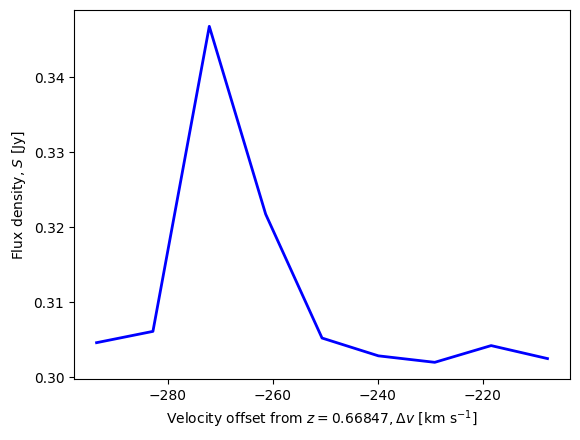

In [11]:
#(ii) Remove and/or replace this and re-plot the spectrum
tmp = df[(df['v'] > -300) & (df['v'] < -200)]
plt.plot(tmp['v'],tmp['Jy'], lw = 2, c = 'b') # LOOKS LIKE 2 BAD CHANNELS
plt.xlabel(r'Velocity offset from $z=0.66847, \Delta v$ [km s$^{-1}$]')
plt.ylabel('Flux density, $S$ [Jy]')

Text(0, 0.5, 'Flux density, $S$ [Jy]')

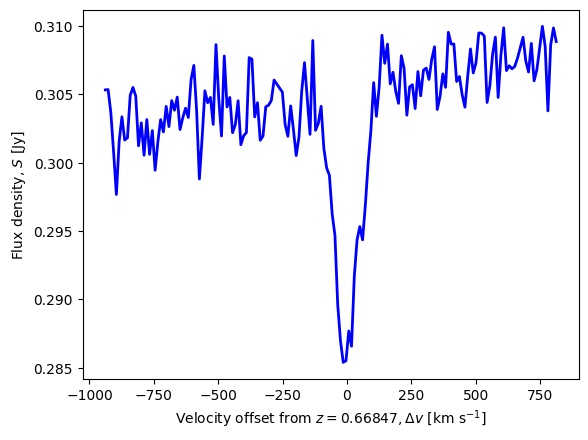

In [13]:
df = df[df['Jy'] < 0.31]  # AGAIN, VARIOUS WAYS TO DO THIS - JUSTING REMOVING ALL THOSE ABOVE 0.31 Jy
plt.plot(df['v'],df['Jy'], lw = 2, c = 'b') # YEP, THAT'S DONE IT
plt.xlabel(r'Velocity offset from $z=0.66847, \Delta v$ [km s$^{-1}$]')
plt.ylabel('Flux density, $S$ [Jy]')

**There still remains a slope in the bandpass (the part of the spectrum not containing the absorption). Using your best judgement of where the absorption begins and ends:**
- (i) Fit a first order polynomial (linear fit) to the absorption free channels
- (ii) Remove this from the spectrum.
- (iii) What is the peak flux of the absorption profile in relation to the bandpass? 
- (iv) What is the rms noise level of the absorption free channels?


In [16]:
#(i) Fit a first order polynomial (linear fit) to the absorption free channels
# From the cursor estimate limits at -98 and 103 km/s.
bp = df[(df['v'] < -98) | (df['v'] > 103)]
x = bp['v']; y = bp['Jy']
m,C = np.polyfit(x,y,1) 
print(m,C)
df1 = df.copy()
df1['bl'] = m*df1['v'] + C  
df1['flux'] = df1['Jy'] - df1['bl'] # REMOVE FIT
df1

3.2811736324778563e-06 0.30532547009242084


,level_0,index,MHz,Jy,v,bl,flux
0,0,732,853.98699,0.305336,-938.361624,0.302247,0.003089
1,1,733,853.95648,0.305358,-927.617552,0.302282,0.003076
2,2,734,853.92596,0.303664,-916.869959,0.302317,0.001347
3,3,735,853.89544,0.300759,-906.122366,0.302352,-0.001594
4,4,736,853.86493,0.297676,-895.378295,0.302388,-0.004712
...,...,...,...,...,...,...,...
159,159,891,849.13500,0.308515,770.262684,0.307853,0.000662
160,160,892,849.10449,0.303800,781.006756,0.307888,-0.004089
161,161,893,849.07397,0.308638,791.754349,0.307923,0.000714
162,162,894,849.04346,0.309870,802.498420,0.307959,0.001912


Text(0, 0.5, 'Flux density, $S$ [Jy]')

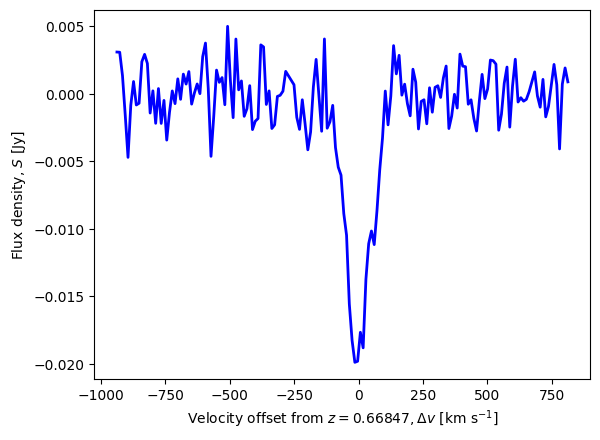

In [18]:
# (ii) Remove this from the spectrum.
df1 = df.copy()
df1['bl'] = m*df1['v'] + C  
df1['flux'] = df1['Jy'] - df1['bl'] # REMOVE FIT

plt.plot(df1['v'],df1['flux'], lw = 2, c = 'b')
plt.xlabel(r'Velocity offset from $z=0.66847, \Delta v$ [km s$^{-1}$]')
plt.ylabel('Flux density, $S$ [Jy]')

In [19]:
# (iii) What is the peak flux of the absorption profile in relation to the bandpass?
y = df1['flux']; x = df1['v']
min_y = y.min(); min_x = x[y.argmin()]
print("Peak flux is %1.3f Jy at %1.1f km/s" %(min_y,min_x))

Peak flux is -0.020 Jy at -35.7 km/s


In [20]:
# What is the rms noise level of the absorption free channels?
# ONE WAY 
df1['flux'].describe()

count    160.000000
mean      -0.001304
std        0.004493
min       -0.019894
25%       -0.002102
50%       -0.000386
75%        0.000963
max        0.004995
Name: flux, dtype: float64

Giving 0.0045 Jy